In [1]:
# Setting of directory of work
import os
os.chdir("D:/DATA_SCIENCE_ENDI/NOTEBOOKS_R/MULTIVARIANTE/MARCELO_WEBSITE/projects/")

# Reading of DataSet at Datsource: IPC - INEC
import pandas as pd

df_ipc = pd.read_excel("IPC/SERIE HISTORICA IPC_05_2025.xls",
                        sheet_name="1. ÍNDICE",
                        skiprows=4,
                        engine="xlrd")

# Find the first row where all cells are empty (NaN)
fila_vacia = df_ipc[df_ipc.isnull().all(axis=1)].index

In [2]:
# If an empty row is found, trim the DataFrame up to that row
if not fila_vacia.empty:
    df_ipc = df_ipc.iloc[:fila_vacia[0]]

# List with the correct names of the columns
nuevos_nombres = ["AÑO",
                  "ENERO", 
                  "FEBRERO",
                  "MARZO",
                  "ABRIL",
                  "MAYO",
                  "JUNIO",
                  "JULIO",
                  "AGOSTO", 
                  "SEPTIEMBRE", 
                  "OCTUBRE",
                  "NOVIEMBRE",
                  "DICIEMBRE"]

# Assign the new names to the DataFrame
df_ipc.columns = nuevos_nombres

In [3]:
# =============================================================================
# Calculation of IPC
# =============================================================================

# Filter of DataFrame IPC desde el año base 2014=100
df_ipc = df_ipc.loc[df_ipc['AÑO'] >= 2014].reset_index(drop=True)

# Ordered list of months
meses = ["ENERO", 
         "FEBRERO",
         "MARZO",
         "ABRIL", 
         "MAYO", 
         "JUNIO",
         "JULIO", 
         "AGOSTO", 
         "SEPTIEMBRE",
         "OCTUBRE",
         "NOVIEMBRE",
         "DICIEMBRE"]

# Create new DataFrame for monthly inflation
df_inflacion = df_ipc[["AÑO"]].copy()

# Base year (2014) equal to 100
df_inflacion.loc[0, meses] = 1

# Calculate monthly inflation for the following years
for i in range(1, len(df_ipc)):
    for j, mes in enumerate(meses):
        valor_actual = df_ipc.loc[i, mes]

        # Skip if None or NaN (case of 2025 from June)
        if pd.isna(valor_actual):
            continue

        if j == 0:
            # JANUARY: use DECEMBER of the preceding year
            valor_anterior = df_ipc.loc[i-1, "DICIEMBRE"]
        else:
            # Rest of months: use the previous month of the same year.
            valor_anterior = df_ipc.loc[i, meses[j-1]]

        # Avoid calculation if previous value is None or NaN
        if pd.isna(valor_anterior):
            continue

        inflacion = ((valor_actual - valor_anterior) / valor_actual) * 100
        df_inflacion.loc[i, mes] = round(inflacion, 2)

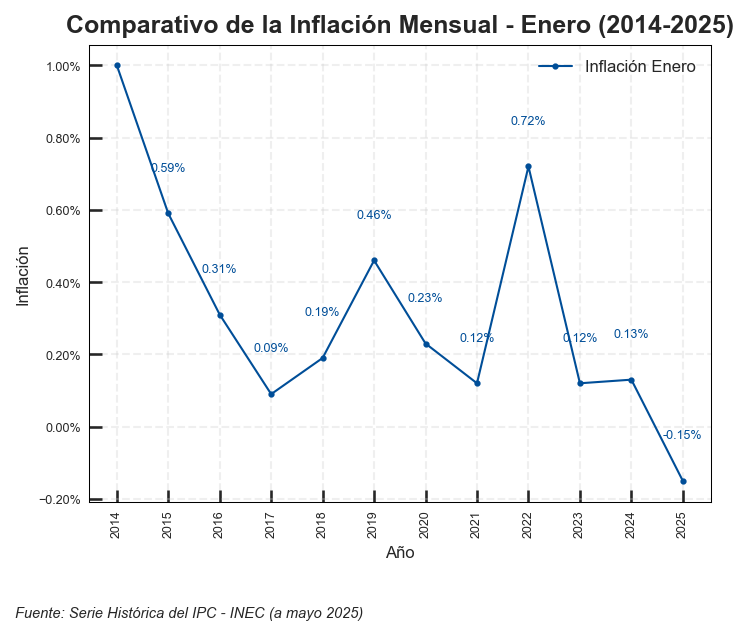

In [4]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Asegurar tipos correctos
df_inflacion["AÑO"] = df_inflacion["AÑO"].astype(int)

# Estilo profesional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")

# Crear figura y ajustar resolución
fig, ax = plt.subplots(figsize=(5, 4), dpi=150)

# Graficar línea fina y puntos pequeños
ax.plot(df_inflacion["AÑO"], 
        df_inflacion["ENERO"],
        marker="o",
        markersize=2,
        linewidth=1,
        color="#004e98",
        label="Inflación Enero")

# Mostrar los valores encima de cada punto, excepto para 2014
for x, y in zip(df_inflacion["AÑO"], df_inflacion["ENERO"]):
    if x != 2014:  # Saltar 2014
        ax.text(x, y+0.11, f"{y:.2f}%", fontsize=6, ha='center', va='bottom', color="#004e98")

# Título y etiquetas
ax.set_title("Comparativo de la Inflación Mensual - Enero (2014-2025)",
             fontsize=12, 
             fontweight='bold')
ax.set_xlabel("Año", fontsize=8)
ax.set_ylabel("Inflación", fontsize=8)

# Mostrar todos los años como ticks
ax.set_xticks(df_inflacion["AÑO"])

# Formato porcentaje
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

# Ticks hacia adentro
ax.tick_params(axis='x', direction='in', labelrotation=90)
ax.tick_params(axis='y', direction='in')
ax.tick_params(labelsize=6)

# Añadir leyenda
ax.legend(loc="upper right", fontsize=8)

# Personalizar cuadrícula
ax.grid(True, linestyle='--', alpha=0.3)

# Añadir bordes negros al gráfico
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)

# Footnote
plt.figtext(0.5, -0.05,
            "Fuente: Serie Histórica del IPC - INEC (a mayo 2025)",
            wrap=True, horizontalalignment='right',
            fontsize=7, style='italic')

# Ajustar layout final
plt.tight_layout()
plt.show()

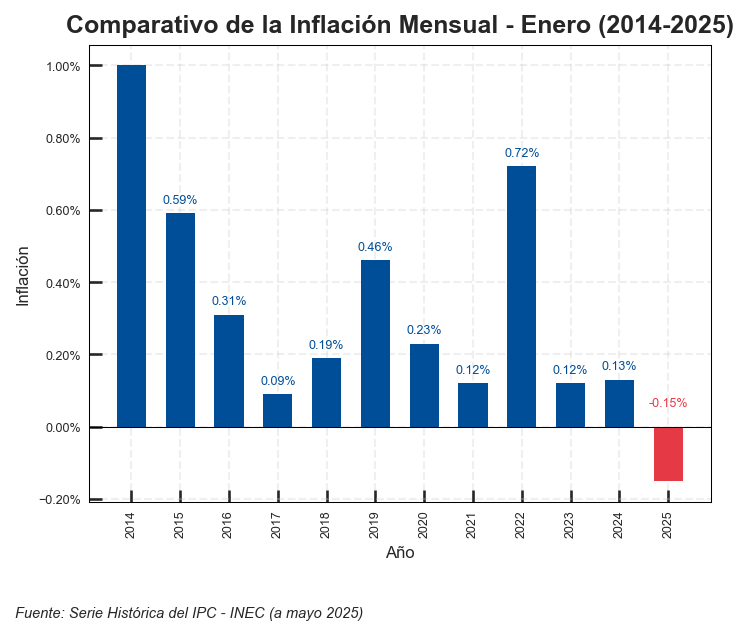

In [41]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Asegurar tipos correctos
df_inflacion["AÑO"] = df_inflacion["AÑO"].astype(int)

# Estilo profesional
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook")

# Crear figura y ajustar resolución
fig, ax = plt.subplots(figsize=(5, 4), dpi=150)

# Graficar barras divergentes
colors = df_inflacion["ENERO"].apply(lambda x: "#004e98" if x >= 0 else "#e63946")  # azul para positivos, rojo para negativos
bars = ax.bar(df_inflacion["AÑO"],
              df_inflacion["ENERO"],
              color=colors,
              width=0.6)

# Mostrar valores encima del eje X para negativos y encima de la barra para positivos, excepto 2014
for x, y in zip(df_inflacion["AÑO"], df_inflacion["ENERO"]):
    if x != 2014:
        label_y = y + 0.02 if y >= 0 else 0.05  # por encima de la barra o del eje X
        ax.text(x, label_y, f"{y:.2f}%", fontsize=6, ha='center', va='bottom',
                color="#004e98" if y >= 0 else "#e63946")

# Título y etiquetas
ax.set_title("Comparativo de la Inflación Mensual - Enero (2014-2025)",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Año", fontsize=8)
ax.set_ylabel("Inflación", fontsize=8)

# Mostrar todos los años como ticks
ax.set_xticks(df_inflacion["AÑO"])

# Formato porcentaje en eje Y
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

# Ticks hacia adentro y tamaño de letra
ax.tick_params(axis='x', direction='in', labelrotation=90, labelsize=6)
ax.tick_params(axis='y', direction='in', labelsize=6)

# Añadir línea base en 0 para referencia
ax.axhline(0, color='black', linewidth=0.5)

# Personalizar cuadrícula
ax.grid(True, linestyle='--', alpha=0.3)

# Añadir bordes negros al gráfico
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)

# Footnote
plt.figtext(0.5, -0.05,
            "Fuente: Serie Histórica del IPC - INEC (a mayo 2025)",
            wrap=True, horizontalalignment='right',
            fontsize=7, style='italic')

# Ajustar layout final
plt.tight_layout()
plt.show()

### Automatización mediante un Pipeline de Datos:

In [35]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

def graficar_inflacion_mensual(df, mes):
    """
    Genera un gráfico de barras divergentes para un mes específico del dataframe de inflación.

    Parámetros:
    - df: DataFrame que contiene al menos las columnas 'AÑO' y el nombre del mes.
    - mes: Nombre del mes (en mayúsculas) como aparece en el DataFrame (por ejemplo: 'ENERO', 'FEBRERO', etc.)
    """
    # Validación básica
    if mes not in df.columns:
        raise ValueError(f"'{mes}' no es una columna válida en el DataFrame.")

    # Asegurar tipos correctos
    df["AÑO"] = df["AÑO"].astype(int)

    # Estilo profesional
    plt.style.use('seaborn-v0_8-whitegrid')
    sns.set_context("notebook")

    # Crear figura
    fig, ax = plt.subplots(figsize=(5, 4), dpi=150)

    # Barras positivas en azul, negativas en rojo
    colors = df[mes].apply(lambda x: "#ff6347" if x >= 0 else "#77dd77")
    bars = ax.bar(df["AÑO"], df[mes], color=colors, width=0.6)

    # Mostrar valores sobre las barras (o sobre el eje X para negativos), excepto 2014
    for x, y in zip(df["AÑO"], df[mes]):
        if x != 2014:
            label_y = y + 0.02 if y >= 0 else 0.05
            ax.text(x, label_y, f"{y:.2f}%", fontsize=6, ha='center', va='bottom',
                    color="#004e98" if y >= 0 else "#228B22")

    # Título dinámico
    ax.set_title(f"Comparativo de la Inflación Mensual - {mes.capitalize()} (2014-2025)",
                 fontsize=12, fontweight='bold')

    # Etiquetas
    ax.set_xlabel("Año", fontsize=8)
    ax.set_ylabel("Inflación", fontsize=8)
    ax.set_xticks(df["AÑO"])

    # Formato porcentaje
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))

    # Estilo de ejes
    ax.tick_params(axis='x', direction='in', labelrotation=90, labelsize=6)
    ax.tick_params(axis='y', direction='in', labelsize=6)

    # Línea base
    ax.axhline(0, color='black', linewidth=0.5)

    # Cuadrícula
    ax.grid(True, linestyle='--', alpha=0.3)

    # Bordes del gráfico
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)

    # Fuente del gráfico
    plt.figtext(0.5, -0.05,
                "Fuente: Serie Histórica del IPC - INEC (a mayo 2025)",
                wrap=True, horizontalalignment='right',
                fontsize=7, style='italic')

    plt.tight_layout()
    plt.show()

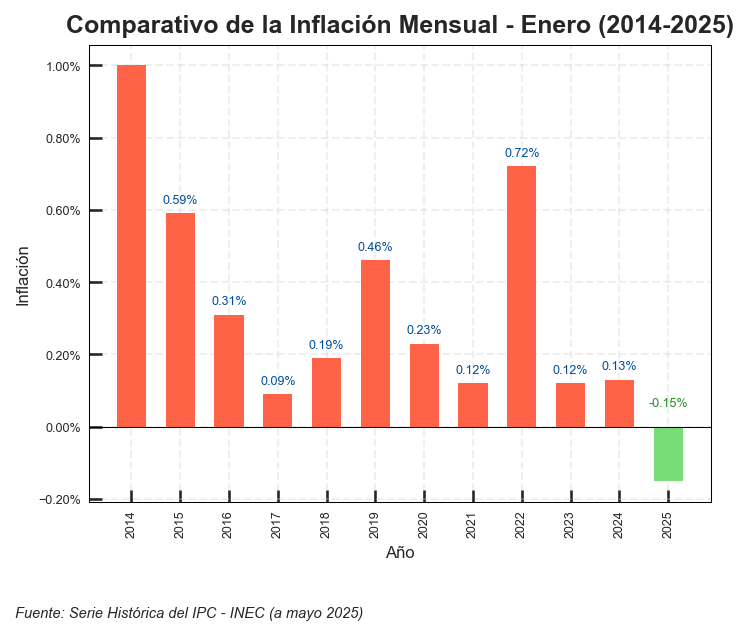

In [36]:
graficar_inflacion_mensual(df_inflacion, "ENERO")


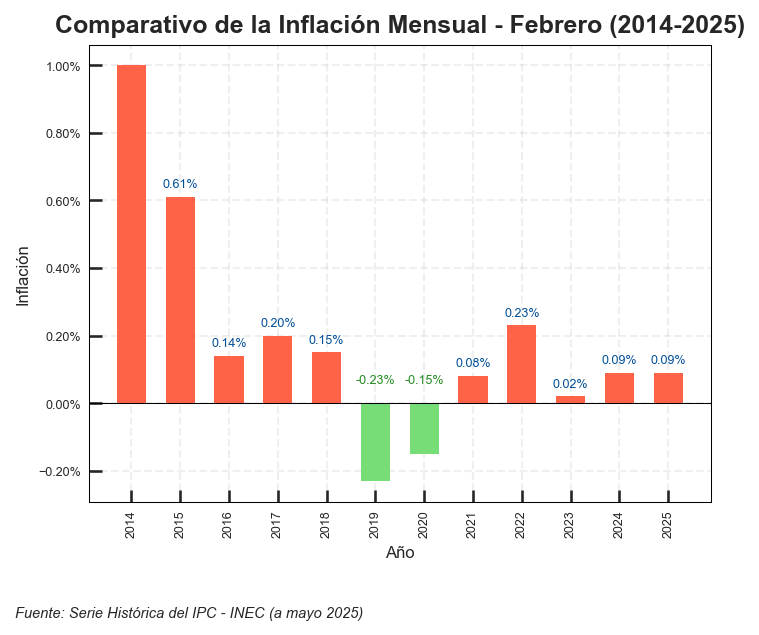

In [37]:
graficar_inflacion_mensual(df_inflacion, "FEBRERO")

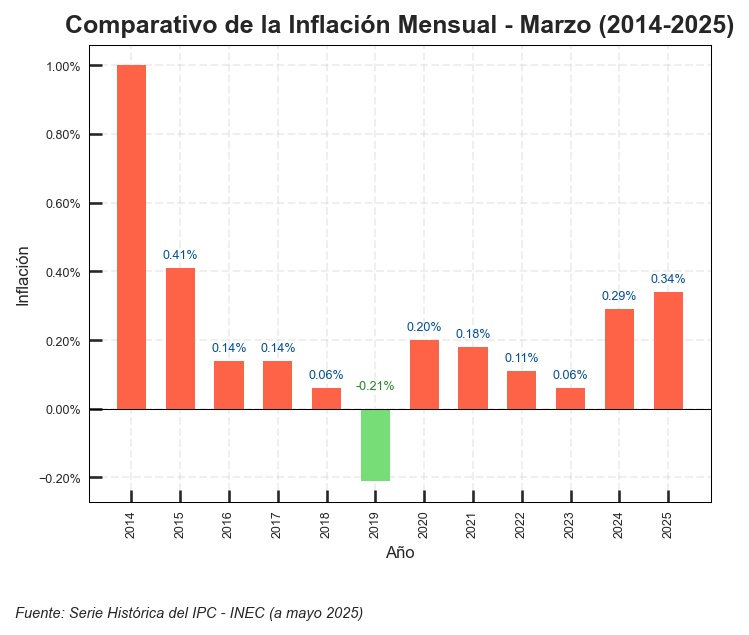

In [38]:
graficar_inflacion_mensual(df_inflacion, "MARZO")

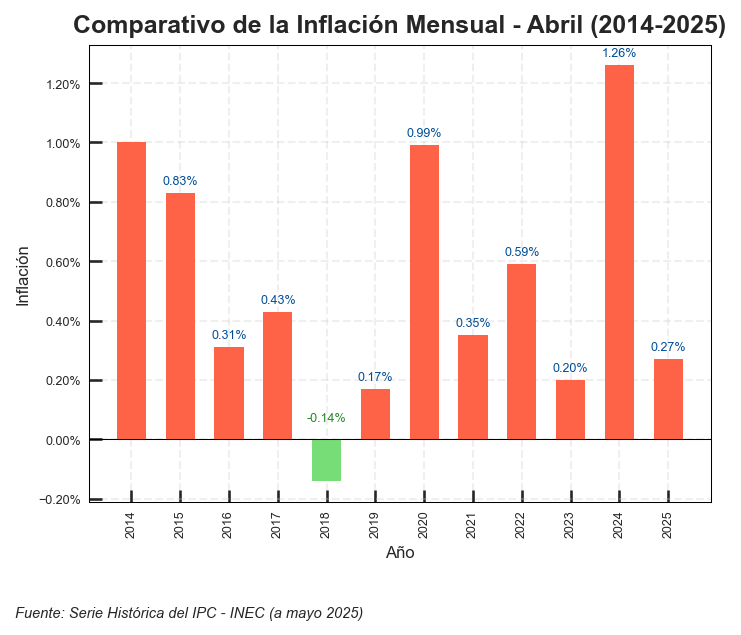

In [39]:
graficar_inflacion_mensual(df_inflacion, "ABRIL")

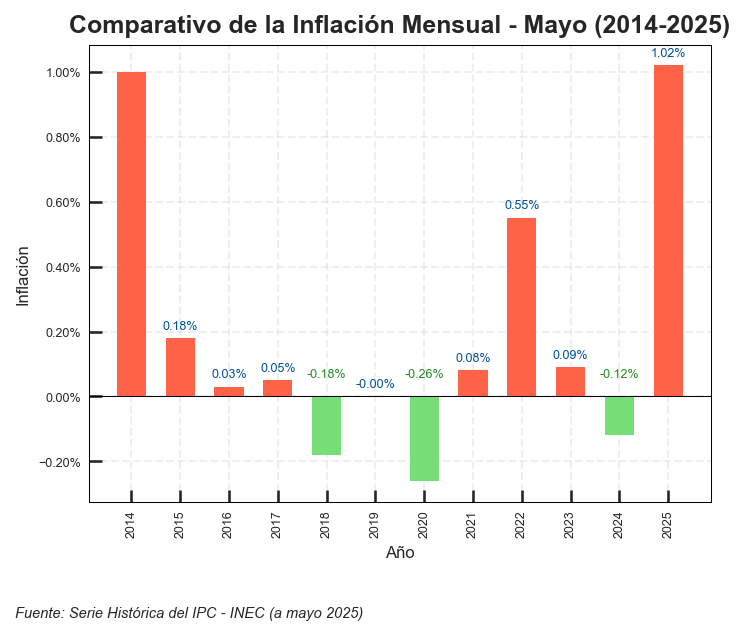

In [40]:
graficar_inflacion_mensual(df_inflacion, "MAYO")

In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

def graficar_inflacion_mensual(df, mes):
    if mes not in df.columns:
        raise ValueError(f"'{mes}' no es una columna válida en el DataFrame.")

    df["AÑO"] = df["AÑO"].astype(int)

    # Usar estilo seaborn
    sns.set_style("whitegrid")
    sns.set_context("notebook")

    fig, ax = plt.subplots(figsize=(6, 4), dpi=150)

    # Paleta personalizada: tomate para positivos, verde pastel para negativos
    palette = sns.color_palette(["#ff6347", "#77dd77"])

    # Crear lista de colores según signo
    colors = [palette[0] if val >= 0 else palette[1] for val in df[mes]]

    bars = ax.bar(df["AÑO"], df[mes], color=colors, width=0.6)

    for x, y in zip(df["AÑO"], df[mes]):
        if x != 2014:
            label_y = y + 0.02 if y >= 0 else 0.05
            color_text = "#004e98" if y >= 0 else "#228B22"
            ax.text(x, label_y, f"{y:.2f}%", fontsize=6, ha='center', va='bottom', color=color_text)

    ax.set_title(f"Comparativo de la Inflación Mensual - {mes.capitalize()} (2014-2025)",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Año", fontsize=8)
    ax.set_ylabel("Inflación", fontsize=8)
    ax.set_xticks(df["AÑO"])

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
    ax.tick_params(axis='x', direction='in', labelrotation=90, labelsize=6)
    ax.tick_params(axis='y', direction='in', labelsize=6)

    ax.axhline(0, color='black', linewidth=0.5)
    ax.grid(True, linestyle='--', alpha=0.3)

    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)

    plt.figtext(0.5, -0.05,
                "Fuente: Serie Histórica del IPC - INEC (a mayo 2025)",
                wrap=True, horizontalalignment='right',
                fontsize=7, style='italic')

    plt.tight_layout()
    plt.show()

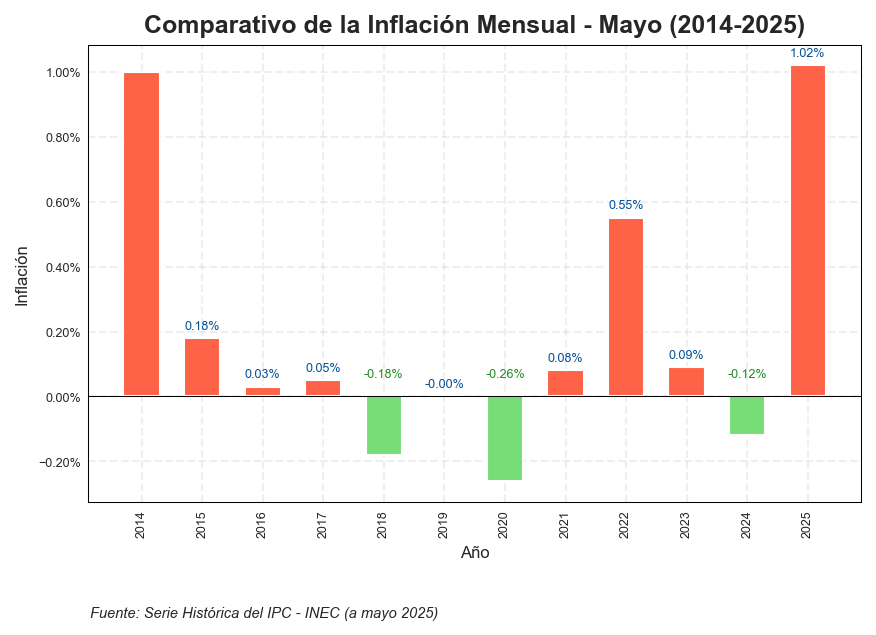

In [43]:
graficar_inflacion_mensual(df_inflacion, "MAYO")

In [44]:
import plotly.express as px
import pandas as pd

def graficar_inflacion_mensual_plotly(df, mes):
    if mes not in df.columns:
        raise ValueError(f"'{mes}' no es una columna válida en el DataFrame.")
    
    df = df.copy()
    df["AÑO"] = df["AÑO"].astype(int)
    
    # Definir color según signo
    df['color'] = df[mes].apply(lambda x: '#ff6347' if x >= 0 else '#77dd77')  # tomate / verde pastel
    
    # Crear gráfico
    fig = px.bar(
        df,
        x='AÑO',
        y=mes,
        color='color',
        color_discrete_map="identity",
        labels={mes: 'Inflación (%)', 'AÑO': 'Año'},
        title=f"Comparativo de la Inflación Mensual - {mes.capitalize()} (2014-2025)"
    )
    
    # Ajustar texto de etiquetas para mostrar el valor en porcentaje
    fig.update_traces(
        text=df[mes].apply(lambda x: f"{x:.2f}%"),
        textposition=['outside' if val >= 0 else 'inside' for val in df[mes]],
        marker_line_color='black', marker_line_width=0.5
    )
    
    # Ajustar layout para que se vea mejor
    fig.update_layout(
        yaxis_tickformat=".2%",
        xaxis_tickangle=90,
        yaxis_title="Inflación",
        xaxis_title="Año",
        uniformtext_minsize=6,
        uniformtext_mode='hide',
        plot_bgcolor='white',
        legend_title_text='',
        showlegend=False,
        margin=dict(t=50, b=80)
    )
    
    # Añadir línea horizontal en cero
    fig.add_hline(y=0, line_color='black', line_width=1)
    
    # Mostrar la figura
    fig.show()

In [45]:
graficar_inflacion_mensual_plotly(df_inflacion, "ENERO")